In [6]:
import pandas as pd
df=pd.read_csv("smartretail_cleaned.csv")

In [7]:
df.head()

,Date,Product_ID,Product_Category,City,Store_Type,Price,Discount_Percentage,Marketing_Spend,Holiday_Flag,Previous_Month_Demand,Season,Next_Month_Demand
0,2025-05-01,FASH104,Fashion,Chennai,Mall,2869.75,0,4568.26,No,476,Summer,447
1,2024-10-01,CARE102,Personal Care,Kolkata,Neighbourhood,552.65,25,29789.71,Yes,549,Festival,1219
2,2025-01-01,ELEC103,Electronics,Mumbai,Supermarket,7501.15,0,12891.77,Yes,296,Winter,395
3,2023-03-01,CARE103,Personal Care,Pune,Mall,153.72,10,28439.45,No,732,Summer,710
4,2023-09-01,GROC101,Groceries,Bengaluru,Neighbourhood,126.60,5,19469.91,No,965,Festival,1283


In [8]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')


In [9]:
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Quarter']=df['Date'].dt.quarter
df=df.sort_values("Date").reset_index(drop=True)
df.head(4)

,Date,Product_ID,Product_Category,City,Store_Type,Price,Discount_Percentage,Marketing_Spend,Holiday_Flag,Previous_Month_Demand,Season,Next_Month_Demand,Year,Month,Quarter
0,2023-01-01,FASH104,Fashion,Delhi,Supermarket,3244.99,5,29923.67,Yes,382,Winter,581,2023,1,1
1,2023-01-01,HOME103,Home Appliances,Delhi,High Street,17350.58,0,19664.24,No,179,Winter,237,2023,1,1
2,2023-01-01,ELEC103,Electronics,Kolkata,Mall,7087.44,0,21899.73,Yes,204,Winter,332,2023,1,1
3,2023-01-01,GROC102,Groceries,Chennai,Mall,257.47,5,26108.80,Yes,1258,Winter,1168,2023,1,1


In [10]:
df=df.drop("Date",axis=1)
print(df.columns.tolist())

['Product_ID', 'Product_Category', 'City', 'Store_Type', 'Price', 'Discount_Percentage', 'Marketing_Spend', 'Holiday_Flag', 'Previous_Month_Demand', 'Season', 'Next_Month_Demand', 'Year', 'Month', 'Quarter']


In [11]:
df['Discounted_Price']=(df["Price"]*(1-df["Discount_Percentage"]/100))

In [12]:
df.head()

,Product_ID,Product_Category,City,Store_Type,Price,Discount_Percentage,Marketing_Spend,Holiday_Flag,Previous_Month_Demand,Season,Next_Month_Demand,Year,Month,Quarter,Discounted_Price
0,FASH104,Fashion,Delhi,Supermarket,3244.99,5,29923.67,Yes,382,Winter,581,2023,1,1,3082.7405
1,HOME103,Home Appliances,Delhi,High Street,17350.58,0,19664.24,No,179,Winter,237,2023,1,1,17350.5800
2,ELEC103,Electronics,Kolkata,Mall,7087.44,0,21899.73,Yes,204,Winter,332,2023,1,1,7087.4400
3,GROC102,Groceries,Chennai,Mall,257.47,5,26108.80,Yes,1258,Winter,1168,2023,1,1,244.5965
4,ELEC102,Electronics,Kochi,Supermarket,24806.91,0,18138.31,Yes,200,Winter,238,2023,1,1,24806.9100


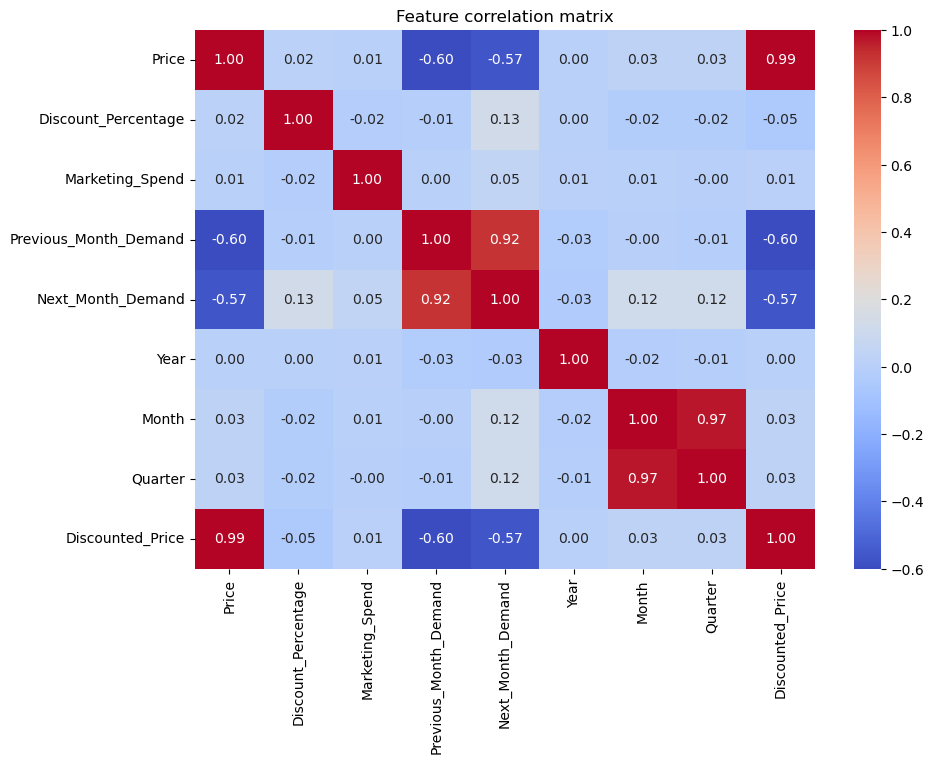

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
numeric_df=df.select_dtypes(include="number")
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm",fmt='.2f')
plt.title("Feature correlation matrix")
plt.show()

In [14]:
X=df.drop("Next_Month_Demand",axis=1)
y=df["Next_Month_Demand"]


In [15]:
X

,Product_ID,Product_Category,City,Store_Type,Price,Discount_Percentage,Marketing_Spend,Holiday_Flag,Previous_Month_Demand,Season,Year,Month,Quarter,Discounted_Price
0,FASH104,Fashion,Delhi,Supermarket,3244.99,5,29923.67,Yes,382,Winter,2023,1,1,3082.7405
1,HOME103,Home Appliances,Delhi,High Street,17350.58,0,19664.24,No,179,Winter,2023,1,1,17350.5800
2,ELEC103,Electronics,Kolkata,Mall,7087.44,0,21899.73,Yes,204,Winter,2023,1,1,7087.4400
3,GROC102,Groceries,Chennai,Mall,257.47,5,26108.80,Yes,1258,Winter,2023,1,1,244.5965
4,ELEC102,Electronics,Kochi,Supermarket,24806.91,0,18138.31,Yes,200,Winter,2023,1,1,24806.9100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,GROC101,Groceries,Pune,High Street,110.47,0,26470.01,Yes,913,Winter,2025,12,4,110.4700
2996,FASH104,Fashion,Pune,High Street,3406.87,15,17073.32,No,337,Winter,2025,12,4,2895.8395
2997,CARE101,Personal Care,Pune,High Street,381.01,0,5180.50,Yes,710,Winter,2025,12,4,381.0100
2998,ELEC102,Electronics,Mumbai,Mall,21724.89,5,29620.97,Yes,268,Winter,2025,12,4,20638.6455


In [16]:
y

0        581
1        237
2        332
3       1168
4        238
        ... 
2995     889
2996     384
2997     572
2998     470
2999     869
Name: Next_Month_Demand, Length: 3000, dtype: int64

In [17]:
train_mask=df['Year'].isin([2023,2024])
test_mask=df['Year']==2025
X_train=X[train_mask]
X_test=X[test_mask]
y_train=y[train_mask]
y_test=y[test_mask]

In [18]:
X_train.shape

(1981, 14)

In [19]:
X_test.shape

(1019, 14)

In [20]:
df.loc[train_mask,'Year'].unique()

array([2023, 2024], dtype=int32)

In [21]:
df.loc[test_mask,'Year'].unique()

array([2025], dtype=int32)

In [22]:


categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numerical_cols = X_train.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Product_ID', 'Product_Category', 'City', 'Store_Type', 'Holiday_Flag', 'Season']

Numerical columns:
['Price', 'Discount_Percentage', 'Marketing_Spend', 'Previous_Month_Demand', 'Year', 'Month', 'Quarter', 'Discounted_Price']


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical',
         OneHotEncoder(handle_unknown='ignore'),
         categorical_cols)
    ],
    remainder='passthrough'
)

In [24]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape :", X_test_processed.shape)

Processed training shape: (1981, 52)
Processed testing shape : (1019, 52)


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [26]:
y_pred = rf_model.predict(X_test_processed)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[ 357.49  1170.96  1596.945  290.315  530.88   338.53   371.175 1004.33
  387.58   348.675]


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 56.31
RMSE: 82.25
R²  : 0.9522


In [28]:
results = pd.DataFrame({
    'Actual_Demand': y_test.values,
    'Predicted_Demand': y_pred
})

print(results.head(10))

   Actual_Demand  Predicted_Demand
0            395           357.490
1           1343          1170.960
2           1966          1596.945
3            231           290.315
4            670           530.880
5            313           338.530
6            379           371.175
7            981          1004.330
8            369           387.580
9            379           348.675


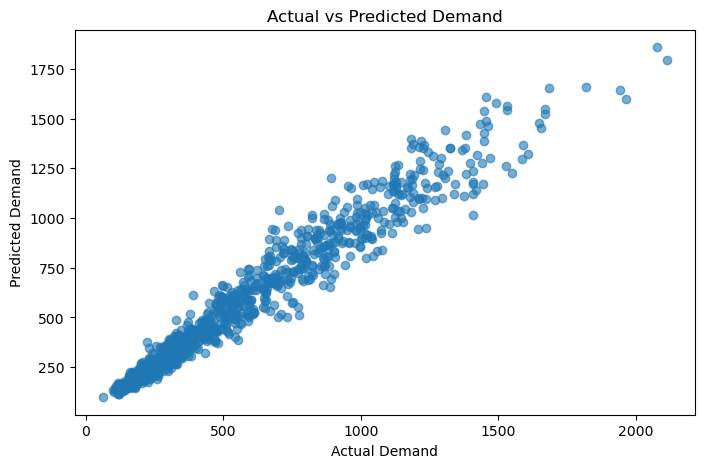

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

In [30]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("MAPE:", round(mape, 2), "%")

MAPE: 10.74 %


In [34]:
import pandas as pd

feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print(feature_importance.head(15))

                                  Feature  Importance
47       remainder__Previous_Month_Demand    0.871515
40           categorical__Season_Festival    0.041718
45         remainder__Discount_Percentage    0.023400
49                       remainder__Month    0.011730
46             remainder__Marketing_Spend    0.008608
51            remainder__Discounted_Price    0.005853
44                       remainder__Price    0.004473
29                categorical__City_Kochi    0.003560
27                categorical__City_Delhi    0.002485
36  categorical__Store_Type_Neighbourhood    0.002347
39          categorical__Holiday_Flag_Yes    0.002334
38           categorical__Holiday_Flag_No    0.002200
31               categorical__City_Mumbai    0.002052
43             categorical__Season_Winter    0.001629
32                 categorical__City_Pune    0.001212


In [35]:
df.columns

Index(['Product_ID', 'Product_Category', 'City', 'Store_Type', 'Price',
       'Discount_Percentage', 'Marketing_Spend', 'Holiday_Flag',
       'Previous_Month_Demand', 'Season', 'Next_Month_Demand', 'Year', 'Month',
       'Quarter', 'Discounted_Price'],
      dtype='object')

In [36]:
def predict_demand(input_data):
    input_df = pd.DataFrame([input_data])

    # Apply the same preprocessing used during training
    input_processed = preprocessor.transform(input_df)

    # Predict next month's demand
    prediction = rf_model.predict(input_processed)[0]

    return round(prediction)


# Example retail scenario
sample_input = {
    'Product_ID': 'P001',
    'Product_Category': 'Electronics',
    'City': 'Kochi',
    'Store_Type': 'Mall',
    'Price': 1500,
    'Discount_Percentage': 10,
    'Marketing_Spend': 20000,
    'Holiday_Flag': 'Yes',
    'Previous_Month_Demand': 800,
    'Season': 'Festival',
    'Year': 2025,
    'Month': 9,
    'Quarter': 3,
    'Discounted_Price': 1350
}

predicted_demand = predict_demand(sample_input)

print("Predicted Next Month Demand:", predicted_demand, "units")

Predicted Next Month Demand: 1014 units


In [37]:
import joblib

joblib.dump(rf_model, "smartretail_random_forest.pkl")
joblib.dump(preprocessor, "smartretail_preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!
